# plotting results

FFDI results as changes


In [1]:
import intake
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

from glob import glob
import pathlib
import traceback
from datetime import datetime



In [2]:
from dask.distributed import Client
import dask

# Set configuration options
dask.config.set({
    'distributed.comm.timeouts.connect': '90s',  # Timeout for connecting to a worker
    'distributed.comm.timeouts.tcp': '90s',  # Timeout for TCP communications
})

#cluster = LocalCluster(
#    n_workers=28,          # Number of workers
#    threads_per_worker=1 #Threads per worker
#    #memory_limit='8GB' # Memory limit per each worker commented out
#)
#client = Client(cluster)

client = Client()
client

2025-09-24 21:46:09,595 - distributed.preloading - INFO - Creating preload: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py
2025-09-24 21:46:09,599 - distributed.utils - INFO - Reload module schedplugin from .py file
2025-09-24 21:46:09,623 - distributed.preloading - INFO - Import preload module: /g/data/hh5/public/apps/dask-optimiser/schedplugin.py


Modifying workers


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/26880/proxy/8787/status,
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/26880/proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37573,Workers: 14
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/26880/proxy/8787/status,Total threads: 14
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35223,Total threads: 1
Dashboard: /node/gadi-cpu-bdw-0039.gadi.nci.org.au/26880/proxy/42475/status,Memory: 0 B
Nanny: tcp://127.0.0.1:42119,


In [3]:
# parameters
dirstore='sa_2090'

## modules

In [4]:
def plot_4(SM1,SM2,SM3,ivar,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    cb1='coolwarm'

    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1); SM1.sel(season=id[ivar]).plot(levels=lev,cmap=cb,extend='max')
    plt.title('2025 '+id[ivar])
    
    plt.subplot(2,2,2); SM2.sel(season=id[ivar]).plot(levels=lev,cmap=cb,extend='max')
    plt.title('2050 '+id[ivar])
    plt.subplot(2,2,3); SM3.sel(season=id[ivar]).plot(levels=lev,cmap=cb,extend='max')
    plt.title('2090 '+id[ivar])
    plt.subplot(2,2,4); (SM3.sel(season=id[ivar]) - SM1.sel(season=id[ivar])).plot(levels=10,cmap=cb1,extend='both')
    plt.title('2090 - 2025 '+id[ivar])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

def plot_2(SM1,SM2,SM3,ivar,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    cb1='coolwarm'

    plt.figure(figsize=(8,4.5))
    plt.subplot(1,2,1); (SM2.sel(season=id[ivar]) - SM1.sel(season=id[ivar])).plot(levels=lev,cmap=cb1,extend='both')
    plt.title('2050s - 2025s ')
    
    plt.subplot(1,2,2); (SM3.sel(season=id[ivar]) - SM1.sel(season=id[ivar])).plot(levels=lev,cmap=cb1,extend='both')
    plt.title('2090s - 2025s ')
# Add global title
    plt.suptitle(tit+ id[ivar])
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

# relative change
def plot_2a(SM1,SM2,SM3,ivar,ndim,id,lev,tit,fname='tmp.png'):
    cb1='plasma'
#    cb1='coolwarm'

    plt.figure(figsize=(8,4.5))
#    plt.subplot(1,2,1); (SM2.sum(dim='season')/ 365.).plot(levels=lev,cmap=cb1,extend='both')
    plt.subplot(1,2,1); (SM2.sum(dim='season')/ SM1.sum(dim='season')).plot(levels=lev,cmap=cb1,extend='both')
    (SM2.sum(dim='season')/ SM1.sum(dim='season')).plot.contour(levels=[1.4, 2],colors='black', linewidths=1)
    plt.title('2050s - 2025s ')
    
    plt.subplot(1,2,2); (SM3.sum(dim='season')/ SM1.sum(dim='season')).plot(levels=lev,cmap=cb1,extend='both')
    (SM3.sum(dim='season')/ SM1.sum(dim='season')).plot.contour(levels=[1.4, 2],colors='black', linewidths=1)
    plt.title('2090s - 2025s ')
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return
    
def plot_4o(SM1,RE,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    mask = RE > 0.25

    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1); SM1.sel(season=id[0]).plot(levels=lev,cmap=cb,extend='max')
#    plt.contourf(RE.lon, RE.lat, mask.sel(season=id[0]), levels=[0.5, 1.5], colors='none',
#            hatches=['', '///'], alpha=.2)
#ax=plt.contourf(mask.lon, mask.lat, mask, levels=[0.5, 1.5], colors='none',
#            hatches=['...', ' '], alpha=0.4 )
# Change hatch color to white
#for collection in ax.collections[-2:]:
#    collection.set_edgecolor("white")
#    collection.set_facecolor("none")   # ensure no fill covers your plot
#    collection.set_linewidth(1.0)

    plt.title(id[0])
    
    plt.subplot(2,2,2); SM1.sel(season=id[1]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[1])
    plt.subplot(2,2,3); SM1.sel(season=id[2]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[2])
    plt.subplot(2,2,4); SM1.sel(season=id[3]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[3])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

In [5]:
#
dirstore0='sa_obs'
dirstore1='sa_2020'
dirstore2='sa_2050'
dirstore3='sa_2090'

dirsave='/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/'
outf1='/scratch/xv83/rxm599/'+dirstore0+'/*_ffdi_ex.nc'
outf2='/scratch/xv83/rxm599/'+dirstore1+'/*_ffdi_ex.nc'
outf3='/scratch/xv83/rxm599/'+dirstore2+'/*_ffdi_ex.nc'
outf4='/scratch/xv83/rxm599/'+dirstore3+'/*_ffdi_ex.nc'

mfiles1 = sorted(glob(outf2))
mfiles2 = sorted(glob(outf3))
mfiles3 = sorted(glob(outf4))

print(outf2)
print(len(mfiles1),len(mfiles2),len(mfiles3))
ds1 = xr.open_mfdataset(outf1, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds2 = xr.open_mfdataset(outf2, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds3 = xr.open_mfdataset(outf3, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds4 = xr.open_mfdataset(outf4, 
    combine="nested",   # treat files as ordered sequence
    concat_dim="model"  # new dimension name
)
ds1

/scratch/xv83/rxm599/sa_2020/*_ffdi_ex.nc
39 39 39


ERROR 1: PROJ: proj_create_from_database: Open of /g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/share/proj failed


0.3.0


<xarray.Dataset>
Dimensions:        (lat: 691, lon: 886, model: 1, season: 4)
Coordinates:
  * lat            (lat) float64 -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon            (lon) float64 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
    quantile       float64 ...
    region         int64 ...
    abbrevs        <U3 ...
    names          <U9 ...
  * season         (season) <U3 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: model
Data variables:
    FFDI_mean      (model, lat, lon) float64 dask.array<chunksize=(1, 691, 886), meta=np.ndarray>
    tot_days       (model, lat, lon, season) float64 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>
    seasonal_clim  (model, lat, lon, season) float32 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>

## Checking plots

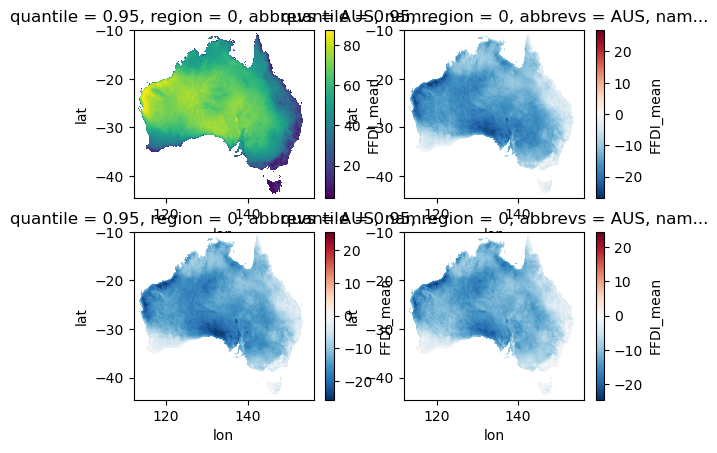

In [6]:
plt.subplot(2,2,1); ds1.FFDI_mean.plot()
plt.subplot(2,2,2); (ds2.FFDI_mean.sel(model=31)-ds1.FFDI_mean).plot()
plt.subplot(2,2,3); (ds3.FFDI_mean.sel(model=31)-ds1.FFDI_mean).plot()
plt.subplot(2,2,4); (ds4.FFDI_mean.sel(model=31)-ds1.FFDI_mean).plot()

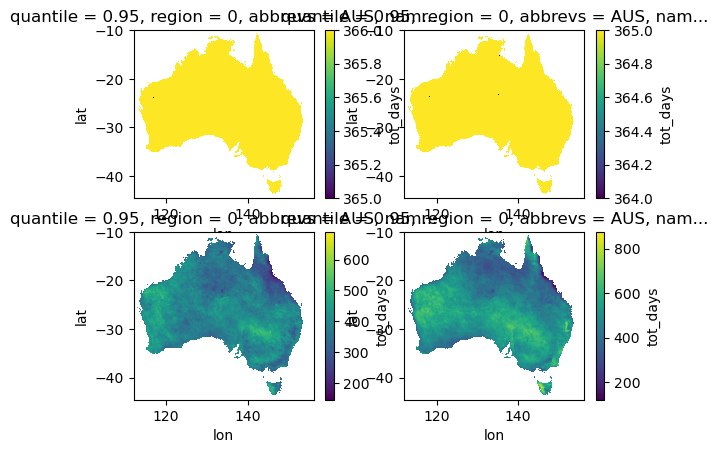

In [7]:
plt.subplot(2,2,1); ds1.tot_days.sum('season',skipna=False).plot()
plt.subplot(2,2,2); (ds2.tot_days.sel(model=31).sum('season',skipna=False)).plot()
plt.subplot(2,2,3); (ds3.tot_days.sel(model=31).sum('season',skipna=False)).plot()
plt.subplot(2,2,4); (ds4.tot_days.sel(model=31).sum('season',skipna=False)).plot()

## Key variables

In [8]:
# Check the total days equals something like 384 (21 years) 
# Needed to ensure all RCMs have 20-years of data
# use Fdays0.sum(dim='season',skipna=False)  to get nan instead of zero too

def check_tdays(Fdays):
    check=Fdays.sum(dim='season')
    max_check=check.max(dim=['lat','lon'])
    scale=366/max_check
#    print(scale.values)
    masked = scale.where(scale <= 2.).load()
    Fdays0=Fdays*masked
    return Fdays0

def check_tdays1(Fdays):
    check=Fdays.sum(dim='season')
    max_check=check.max(dim=['lat','lon'])
    scale=max_check*0+1
    masked=scale.where(max_check >= 100)
#    print(scale.values)
    Fdays0=Fdays*masked
    return Fdays0

In [9]:
FM0=ds1.FFDI_mean.mean(dim='model')
FS0=ds1.FFDI_mean.std(dim='model')
Rerr0=FS0/FM0

FM1=ds2.FFDI_mean.mean(dim='model')
FS1=ds2.FFDI_mean.std(dim='model')
Rerr1=FS1/FM1
FM2=ds3.FFDI_mean.mean(dim='model')
FS2=ds3.FFDI_mean.std(dim='model')
Rerr2=FS2/FM2
FM3=ds4.FFDI_mean.mean(dim='model')
FS3=ds4.FFDI_mean.std(dim='model')
Rerr3=FS3/FM3

Fdays0=ds1.tot_days
Fmean0=ds1.seasonal_clim

Fdays1t=ds2.tot_days
Fmean1=ds2.seasonal_clim
Fdays2t=ds3.tot_days
Fmean2=ds3.seasonal_clim
Fdays3t=ds4.tot_days
Fmean3=ds4.seasonal_clim

Fdays1=check_tdays(Fdays1t)
Fdays2=check_tdays1(Fdays2t)
Fdays3=check_tdays1(Fdays3t)

check=Fdays1.sum(dim='season',skipna=False)
print(check.mean(dim=['lat','lon']).values)
check=Fdays2.sum(dim='season',skipna=False)
print(check.mean(dim=['lat','lon']).values)
check=Fdays3.sum(dim='season',skipna=False)
print(check.mean(dim=['lat','lon']).values)

[365.99986702 365.99988452 365.99985224 365.99987026 365.99991734
 365.9998778  365.99986305 365.99989218 365.99985624 365.99989909
 365.99987386 365.99989937 365.99986666 365.9998162  365.99989577
 365.99986702 365.99984546 365.99984905 365.99985624 365.9998778
 365.99986305 365.9998198  365.99982461 365.99986115 365.99986298
 365.99988107 365.99987747 365.99986305 365.99989188 365.99985945
 365.99989909 365.99985224 365.99983782 365.99982701 365.99987747
 365.99988107 365.99985584 365.99984864 365.99985584]
[439.60858549          nan 403.4814924  586.79969235 434.92900657
 429.69310336 464.73279255 418.45576613 739.10602472 400.81805799
 562.06114931 381.99969091 414.52109173 397.38383464 651.96072054
 600.6717259  504.0564986  461.11543396 429.49681746 421.56554304
 409.92794991 396.82858858 639.11007522 630.67742608 332.06601207
 472.18160777 407.19787807 610.99011634 537.31366784 447.42189932
 477.12535716 387.13776744 454.7783113  452.50548992 476.80271855
 552.95590809 516.62758

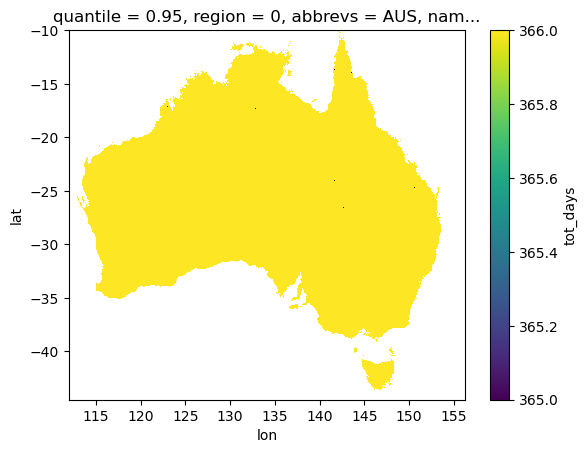

In [10]:
# check the model = 11 is correct for limit data for first period and nan for the other periods
Fdays1.sel(model=11).sum(dim='season',skipna=False).plot() 

## Start plotting

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/ffdi_change_sa_2090.png


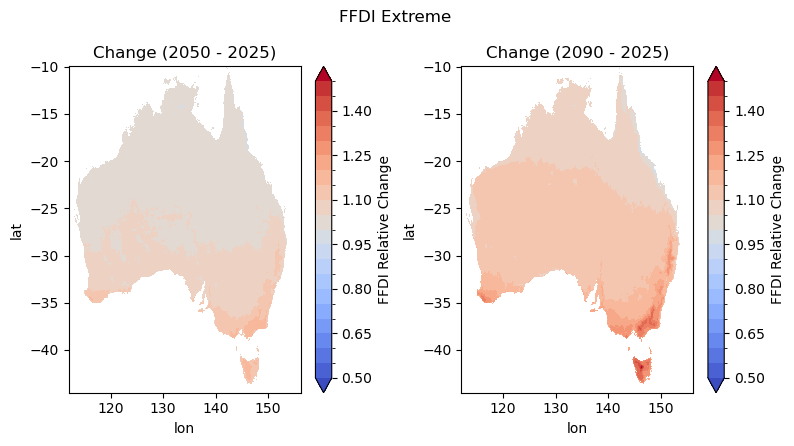

In [11]:
# plot FFDI extreme and relative error
plt.figure(figsize=(8,4.5))
    
plt.subplot(1,2,1)
lev = np.linspace(0.5, 1.5, 21)
cb2='coolwarm'
ax=(FM2/FM1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('Change (2050 - 2025)')
colorbar.set_label('FFDI Relative Change')
ax=plt.tight_layout()

lev = np.linspace(0.5, 1.5, 21)
plt.subplot(1,2,2)
cb2='coolwarm'
ax=(FM3/FM1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('Change (2090 - 2025)')
colorbar.set_label('FFDI Relative Change')

# Add global title
plt.suptitle('FFDI Extreme')
ax=plt.tight_layout()


fname=dirsave+'ffdi_change_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/ffdi_error_sa_2090.png


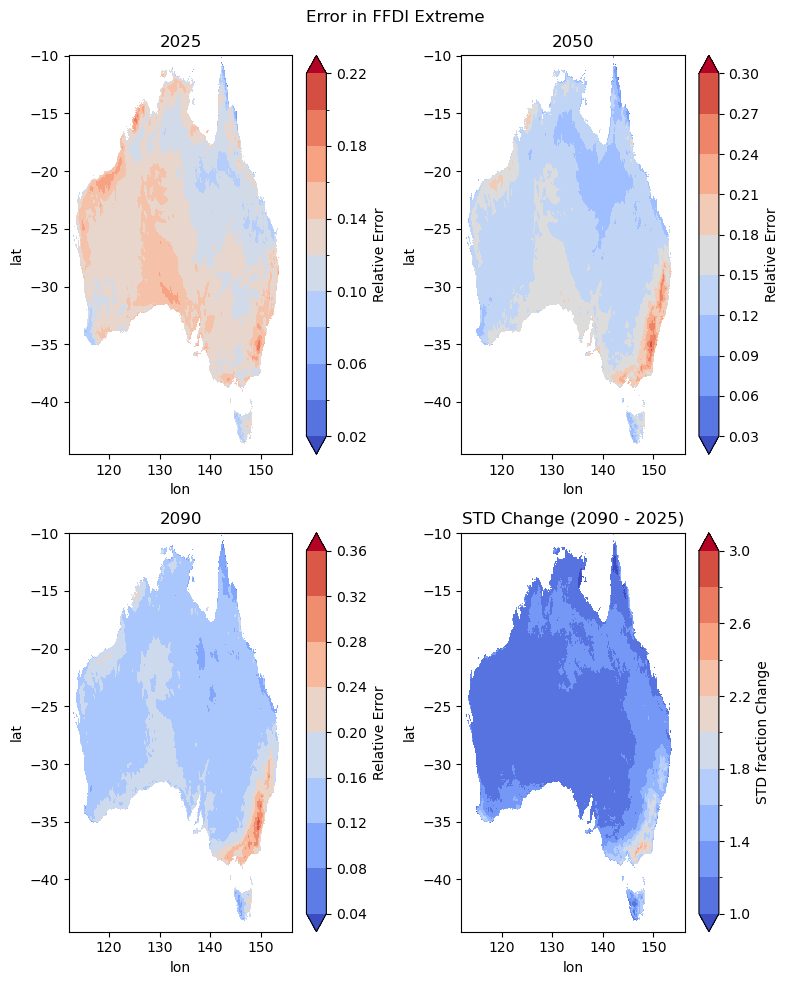

In [12]:
plt.figure(figsize=(8,10))
plt.subplot(2,2,1)
lev = np.linspace(0.0, 2, 11)
lev = 10
ax=(Rerr1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('2025')
colorbar.set_label('Relative Error')
ax=plt.tight_layout()

plt.subplot(2,2,2)
lev = np.linspace(0.0, 2, 11)
lev = 10
ax=(Rerr2).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('2050')
colorbar.set_label('Relative Error')
ax=plt.tight_layout()

plt.subplot(2,2,3)
lev = np.linspace(0.0, 2, 11)
lev = 10
ax=(Rerr3).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('2090')
colorbar.set_label('Relative Error')
ax=plt.tight_layout()

plt.subplot(2,2,4)
lev = np.linspace(1.0, 3, 11)
#lev = 10
ax=(Rerr3/Rerr1).plot(cmap=cb2,levels=lev,extend='both')
colorbar=ax.colorbar
ax=plt.title('STD Change (2090 - 2025)')
colorbar.set_label('STD fraction Change')
# Add global title
plt.suptitle('Error in FFDI Extreme')
ax=plt.tight_layout()

fname=dirsave+'ffdi_error_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

def plot_4o(SM1,RE,ndim,id,lev,tit,fname='tmp.png'):
    cb='plasma'
    mask = RE > 0.25

    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1); SM1.sel(season=id[0]).plot(levels=lev,cmap=cb,extend='max')
#    plt.contourf(RE.lon, RE.lat, mask.sel(season=id[0]), levels=[0.5, 1.5], colors='none',
#            hatches=['', '///'], alpha=.2)
#ax=plt.contourf(mask.lon, mask.lat, mask, levels=[0.5, 1.5], colors='none',
#            hatches=['...', ' '], alpha=0.4 )
# Change hatch color to white
#for collection in ax.collections[-2:]:
#    collection.set_edgecolor("white")
#    collection.set_facecolor("none")   # ensure no fill covers your plot
#    collection.set_linewidth(1.0)

    plt.title(id[0])
    
    plt.subplot(2,2,2); SM1.sel(season=id[1]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[1])
    plt.subplot(2,2,3); SM1.sel(season=id[2]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[2])
    plt.subplot(2,2,4); SM1.sel(season=id[3]).plot(levels=lev,cmap=cb,extend='max')
    plt.title(id[3])
# Add global title
    plt.suptitle(tit)
# Adjust layout so titles don’t overlap
    plt.tight_layout()

    plt.savefig(fname, dpi=150, bbox_inches="tight")
    return

In [13]:
## %%time
# variables storing seasonal number of days and mean values
# filter data based on relative error from multiple simulations
def filter(F):
    SM = F.mean(dim='model')
    SE = F.std(dim='model')
    RE = SE/(SM+1e-1)
    SF= SM.where(RE < .5)
    return SM,SF,RE

Sdays0,SFdays0,Rdays0= filter(Fdays0)
Smean0,SFmean0,Rmean0= filter(Fmean0)
Sdays1,SFdays1,Rdays1= filter(Fdays1)
Smean1,SFmean1,Rmean1= filter(Fmean1)
Sdays2,SFdays2,Rdays2= filter(Fdays2)
Smean2,SFmean2,Rmean2= filter(Fmean2)
Sdays3,SFdays3,Rdays3= filter(Fdays3)
Smean3,SFmean3,Rmean3= filter(Fmean3)


/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_DJF_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


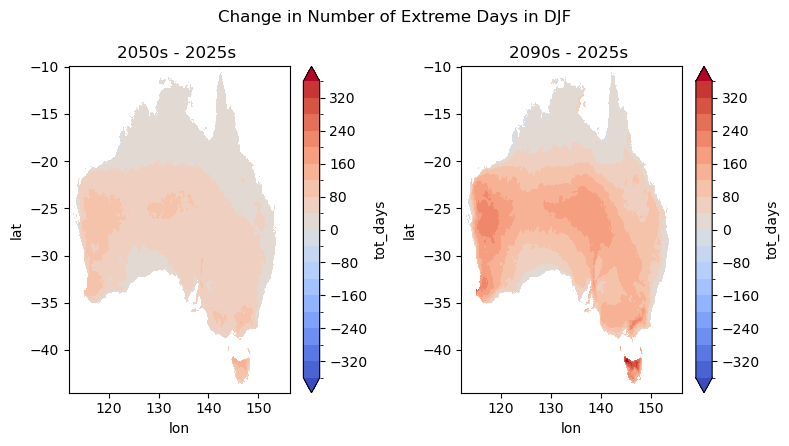

In [14]:
SM2=SFdays1
SM2=Sdays1
SM3=Sdays2
SM4=Sdays3
nvar=SM2.season.values
fname=dirsave+'change_DJF_days_'+dirstore+'.png'
lev = np.linspace(-360, 360, 19)
titl='Change in Number of Extreme Days in '
print(fname)
print(nvar)
plot_2(SM2,SM3,SM4,0,'season',nvar,lev, titl, fname)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_DJF_error_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


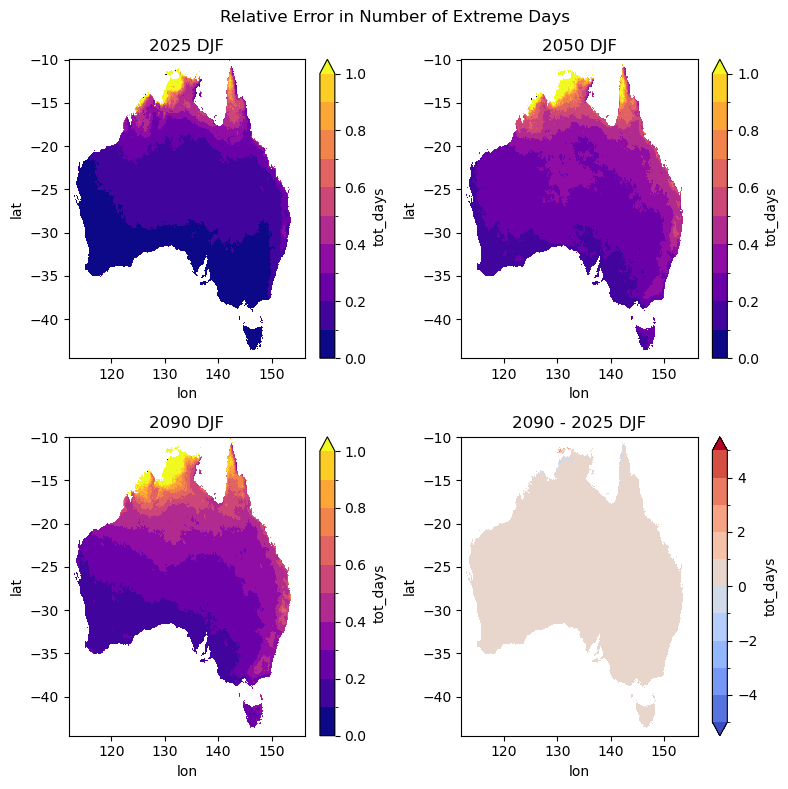

In [15]:
SM2=SFdays1
SM2=Rdays1
SM3=Rdays2
SM4=Rdays3
nvar=SM2.season.values
fname=dirsave+'change_DJF_error_'+dirstore+'.png'
lev = 21  #np.linspace(0, 360, 19)
lev =np.linspace(0, 1, 11)
titl='Relative Error in Number of Extreme Days'
print(fname)
print(nvar)
plot_4(SM2,SM3,SM4,0,'season',nvar,lev, titl, fname)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_SON_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


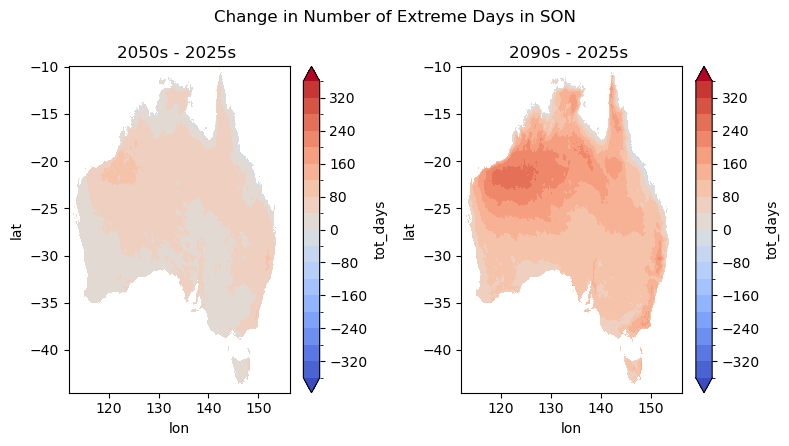

In [16]:
SM2=SFdays1
SM2=Sdays1
SM3=Sdays2
SM4=Sdays3
nvar=SM2.season.values
fname=dirsave+'change_SON_days_'+dirstore+'.png'
lev = np.linspace(-360, 360, 19)
titl='Change in Number of Extreme Days in '
print(fname)
print(nvar)
plot_2(SM2,SM3,SM4,3,'season',nvar,lev, titl, fname)

## Total change in number of days (contour 1.4 and 2)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_year_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


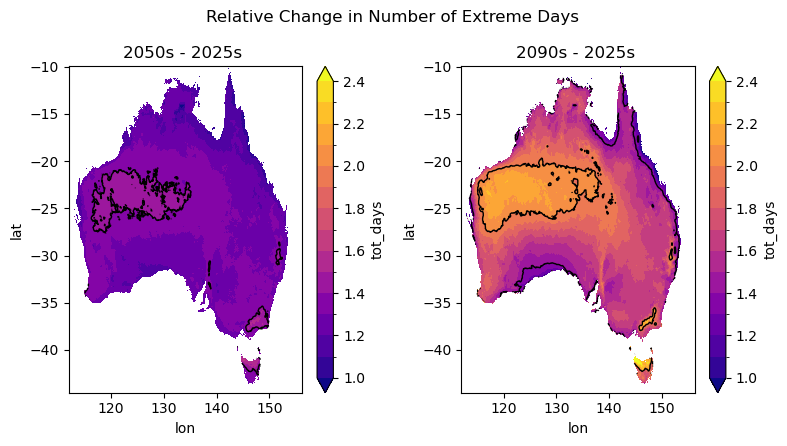

In [17]:
SM2=SFdays1
SM2=Sdays1
SM3=Sdays2
SM4=Sdays3
nvar=SM2.season.values
fname=dirsave+'change_year_days_'+dirstore+'.png'
lev = np.linspace(-2.4, 2.4, 13)
lev = np.linspace(1, 2.4, 15)
titl='Relative Change in Number of Extreme Days '
print(fname)
print(nvar)
plot_2a(SM2,SM3,SM4,3,'season',nvar,lev, titl, fname)

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/change_SON_error_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/numpy_compat.py:51: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


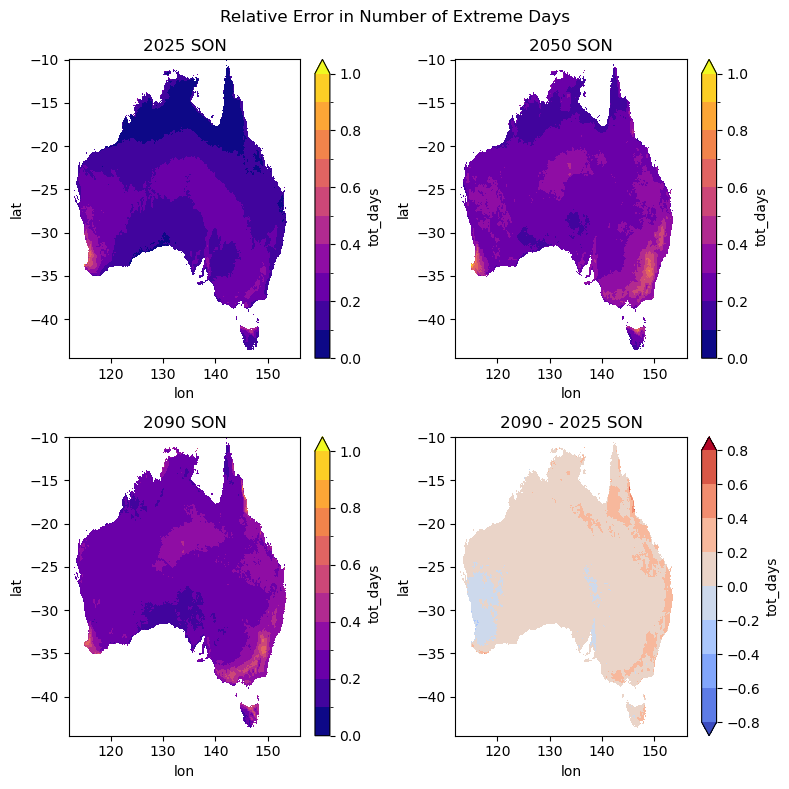

In [18]:
SM2=SFdays1
SM2=Rdays1
SM3=Rdays2
SM4=Rdays3
nvar=SM2.season.values
fname=dirsave+'change_SON_error_'+dirstore+'.png'
lev =np.linspace(0, 1, 11)
titl='Relative Error in Number of Extreme Days'
print(fname)
print(nvar)
plot_4(SM2,SM3,SM4,3,'season',nvar,lev, titl, fname)

## Trying to identify extreme RCMs

In [19]:
# function to find extreme models based on RMSE and mean deviation

def extreme(FD):
# Ensemble mean
    mean_field = FD.mean(dim="model")
# Deviation of each member from mean
    diff = FD - mean_field
# 1. RMSE (overall difference)
    rmse = np.sqrt((diff**2).mean(dim=("lat", "lon")))
# 2. Mean signed deviation (positive vs negative)
    mean_dev = diff.mean(dim=("lat", "lon"))
#### Find members with most positive and most negative mean deviation
    most_positive = mean_dev.argmax(dim="model").values
    most_negative = mean_dev.argmin(dim="model").values
    most_diff = rmse.argmax(dim='model').values

    print("\nModel most above mean (on average):", most_positive)
    print("Model most below mean (on average):", most_negative)
    print("Model most different:", most_diff,"rmse=",rmse.sel(model=most_diff).values)

# Sort by RMSE values along the "model" dimension
    rmse_sorted = rmse.sortby(rmse)
# Extract the sorted model IDs
    sorted_models = rmse["model"].sortby(rmse).values
    sorted_diff = mean_dev.sortby(rmse).values
# Print ranking
    print("Ranking of models (closest → farthest from mean):")
    for rank, (m, score,sc2) in enumerate(zip(sorted_models, rmse_sorted.values, sorted_diff), 1):
        print(f"{rank:2d}: Model {m}, RMSE = {score:.4f}, MD = {sc2:.6f}")
    return


In [20]:
#2090s
FD=Fdays3.sum(dim='season',skipna=False)
extreme(FD)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)



Model most above mean (on average): 8
Model most below mean (on average): 38
Model most different: 8 rmse= 494.6990594180099
Ranking of models (closest → farthest from mean):
 1: Model 2, RMSE = 67.9000, MD = -30.410228
 2: Model 6, RMSE = 68.0221, MD = 15.988248
 3: Model 28, RMSE = 68.7376, MD = 35.508859
 4: Model 20, RMSE = 75.0589, MD = -46.245337
 5: Model 9, RMSE = 81.0698, MD = -23.437712
 6: Model 34, RMSE = 81.2336, MD = -39.522446
 7: Model 25, RMSE = 82.0434, MD = -7.193593
 8: Model 18, RMSE = 82.2790, MD = -52.484399
 9: Model 29, RMSE = 82.6646, MD = -23.276745
10: Model 3, RMSE = 84.1970, MD = 56.167038
11: Model 11, RMSE = 84.3034, MD = -54.479224
12: Model 21, RMSE = 88.6706, MD = -66.793596
13: Model 32, RMSE = 90.1890, MD = 18.312605
14: Model 19, RMSE = 93.4320, MD = -70.095878
15: Model 33, RMSE = 94.8176, MD = 18.812370
16: Model 36, RMSE = 98.5280, MD = -1.763934
17: Model 5, RMSE = 101.2469, MD = -80.558311
18: Model 30, RMSE = 112.0510, MD = -71.110171
19: Mo

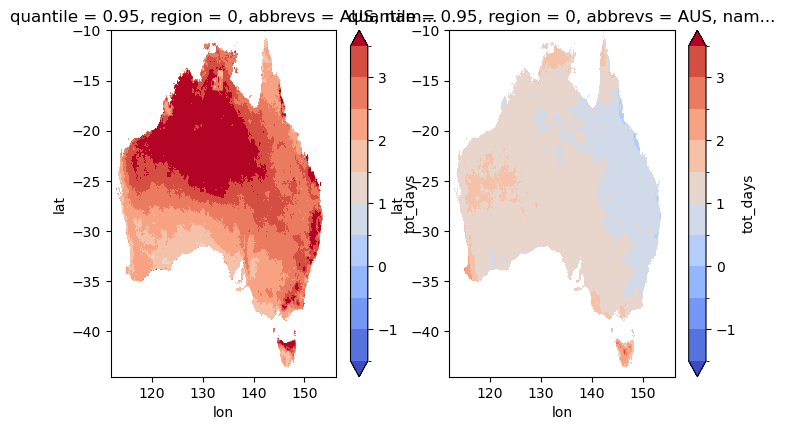

In [21]:
# two extremes

cb1='coolwarm'
#(FD.sel(model=20)-FD.sel(model=3)).plot()
lev = np.linspace(-1.5, 3.5, 11)
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1); (FD.sel(model=8)/365).plot(levels=lev,cmap=cb1,extend='both')
plt.subplot(1,2,2); (FD.sel(model=38)/365).plot(levels=lev,cmap=cb1,extend='both')

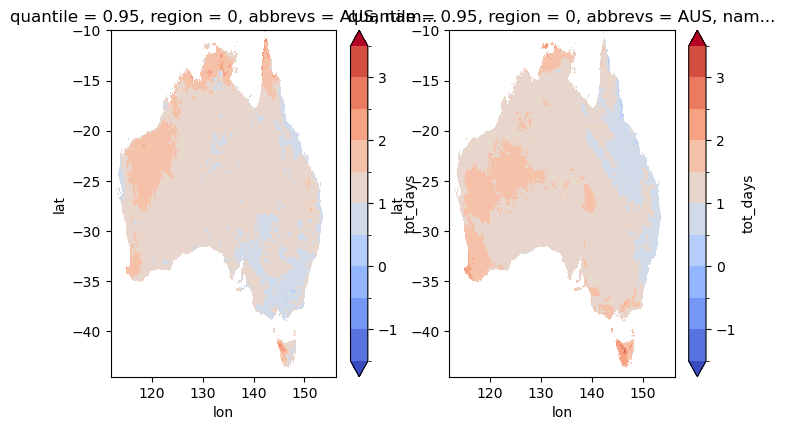

In [22]:
# two extremes

cb1='coolwarm'
#(FD.sel(model=20)-FD.sel(model=3)).plot()
lev = np.linspace(-1.5, 3.5, 11)
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1); (FD.sel(model=12)/365).plot(levels=lev,cmap=cb1,extend='both')
plt.subplot(1,2,2); (FD.sel(model=37)/365).plot(levels=lev,cmap=cb1,extend='both')

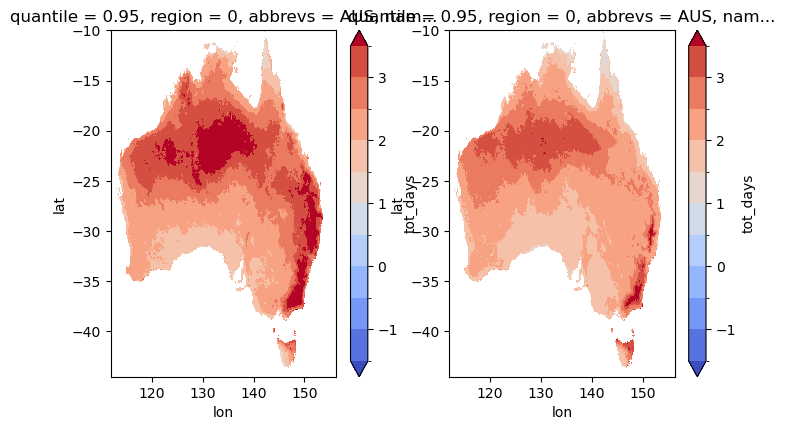

In [23]:
# two extremes

cb1='coolwarm'
#(FD.sel(model=20)-FD.sel(model=3)).plot()
lev = np.linspace(-1.5, 3.5, 11)
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1); (FD.sel(model=14)/365).plot(levels=lev,cmap=cb1,extend='both')
plt.subplot(1,2,2); (FD.sel(model=15)/365).plot(levels=lev,cmap=cb1,extend='both')

###  2050s

In [24]:
# 2050s
FD=Fdays2.sum(dim='season',skipna=False)
extreme(FD)

/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)



Model most above mean (on average): 8
Model most below mean (on average): 24
Model most different: 8 rmse= 302.24966209712466
Ranking of models (closest → farthest from mean):
 1: Model 17, RMSE = 45.5115, MD = -14.243311
 2: Model 6, RMSE = 46.5700, MD = -10.625953
 3: Model 34, RMSE = 52.1070, MD = 1.443973
 4: Model 30, RMSE = 55.4263, MD = 1.766612
 5: Model 25, RMSE = 56.8838, MD = -3.177138
 6: Model 32, RMSE = 60.1737, MD = -20.580434
 7: Model 0, RMSE = 60.4123, MD = -35.750160
 8: Model 33, RMSE = 62.6268, MD = -22.853255
 9: Model 16, RMSE = 64.3070, MD = 28.697753
10: Model 36, RMSE = 65.1488, MD = 41.268842
11: Model 18, RMSE = 66.9886, MD = -45.861928
12: Model 5, RMSE = 70.6812, MD = -45.665642
13: Model 4, RMSE = 72.1440, MD = -40.429739
14: Model 29, RMSE = 73.4906, MD = -27.936846
15: Model 19, RMSE = 74.1237, MD = -53.793202
16: Model 20, RMSE = 76.3681, MD = -65.430795
17: Model 12, RMSE = 78.8523, MD = -60.837654
18: Model 26, RMSE = 82.0445, MD = -68.160867
19: Mo

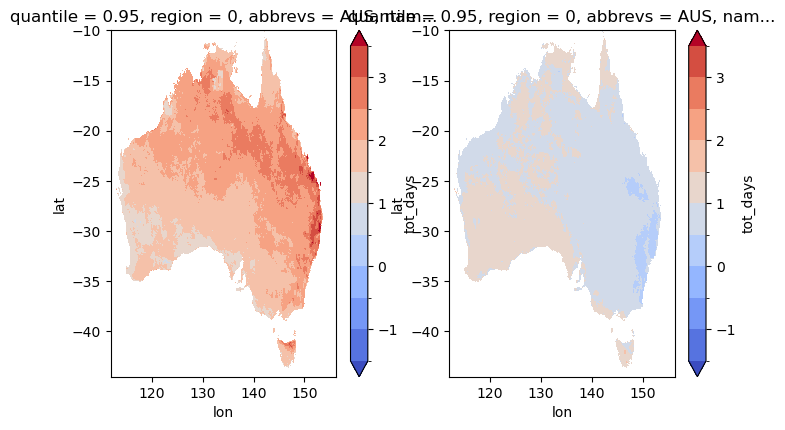

In [25]:
# two extremes

cb1='coolwarm'
#(FD.sel(model=20)-FD.sel(model=3)).plot()
lev = np.linspace(-1.5, 3.5, 11)
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1); (FD.sel(model=8)/365).plot(levels=lev,cmap=cb1,extend='both')
plt.subplot(1,2,2); (FD.sel(model=24)/365).plot(levels=lev,cmap=cb1,extend='both')

### 2025s

In [26]:
# 2025s
FD=Fdays1.sum(dim='season',skipna=False)
extreme(FD)


Model most above mean (on average): 4
Model most below mean (on average): 13
Model most different: 13 rmse= 0.013354616649196887
Ranking of models (closest → farthest from mean):
 1: Model 4, RMSE = 0.0091, MD = 0.000052
 2: Model 11, RMSE = 0.0099, MD = 0.000034
 3: Model 9, RMSE = 0.0100, MD = 0.000033
 4: Model 30, RMSE = 0.0100, MD = 0.000033
 5: Model 14, RMSE = 0.0101, MD = 0.000030
 6: Model 7, RMSE = 0.0103, MD = 0.000026
 7: Model 28, RMSE = 0.0103, MD = 0.000026
 8: Model 35, RMSE = 0.0108, MD = 0.000015
 9: Model 25, RMSE = 0.0108, MD = 0.000015
10: Model 5, RMSE = 0.0109, MD = 0.000012
11: Model 19, RMSE = 0.0109, MD = 0.000012
12: Model 26, RMSE = 0.0110, MD = 0.000012
13: Model 34, RMSE = 0.0110, MD = 0.000012
14: Model 10, RMSE = 0.0111, MD = 0.000008
15: Model 3, RMSE = 0.0113, MD = 0.000004
16: Model 24, RMSE = 0.0113, MD = -0.000003
17: Model 0, RMSE = 0.0114, MD = 0.000001
18: Model 15, RMSE = 0.0114, MD = 0.000001
19: Model 12, RMSE = 0.0114, MD = 0.000001
20: Mode

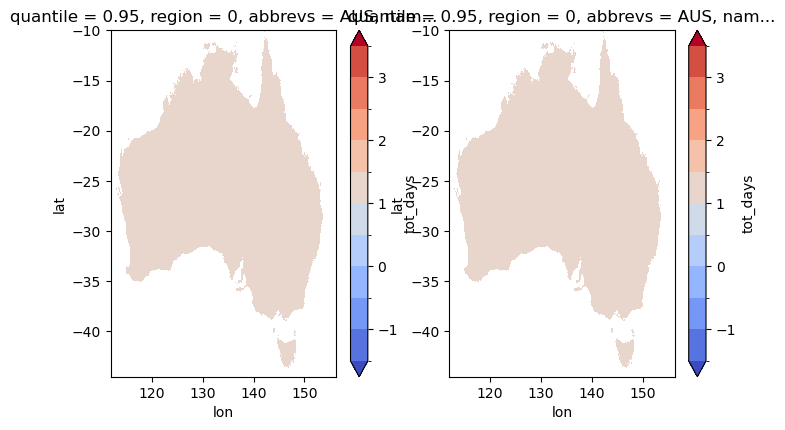

In [27]:
# two extremes

cb1='coolwarm'
#(FD.sel(model=20)-FD.sel(model=3)).plot()
lev = np.linspace(-1.5, 3.5, 11)
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1); (FD.sel(model=4)/365).plot(levels=lev,cmap=cb1,extend='both')
plt.subplot(1,2,2); (FD.sel(model=13)/365).plot(levels=lev,cmap=cb1,extend='both')

In [35]:
# 2025s
FD=Fmean3.mean(dim='season')
extreme(FD)


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.10/lib/python3.10/site-packages/dask/array/reductions.py:1114: RuntimeWarning: All-NaN slice encountered
  vals = func(x, axis=arg_axis, keepdims=True)



Model most above mean (on average): 13
Model most below mean (on average): 32
Model most different: 32 rmse= 12.449215
Ranking of models (closest → farthest from mean):
 1: Model 16, RMSE = 4.5241, MD = 3.828770
 2: Model 4, RMSE = 4.8481, MD = 4.140990
 3: Model 7, RMSE = 5.1859, MD = 2.204438
 4: Model 17, RMSE = 5.4355, MD = 4.835793
 5: Model 19, RMSE = 5.8869, MD = 5.148436
 6: Model 12, RMSE = 5.9315, MD = 5.109820
 7: Model 3, RMSE = 6.0759, MD = 5.453662
 8: Model 18, RMSE = 6.1586, MD = 5.417376
 9: Model 11, RMSE = 6.4745, MD = 5.654896
10: Model 8, RMSE = 6.5855, MD = 5.755689
11: Model 5, RMSE = 6.8507, MD = 5.972533
12: Model 23, RMSE = 6.9957, MD = 6.495784
13: Model 22, RMSE = 7.1780, MD = 6.629051
14: Model 0, RMSE = 7.4355, MD = 6.618778
15: Model 10, RMSE = 7.7255, MD = 6.180547
16: Model 15, RMSE = 8.3952, MD = 7.762015
17: Model 25, RMSE = 8.5197, MD = -7.856900
18: Model 14, RMSE = 8.5348, MD = 7.951326
19: Model 6, RMSE = 8.5611, MD = 7.670712
20: Model 20, RMSE 

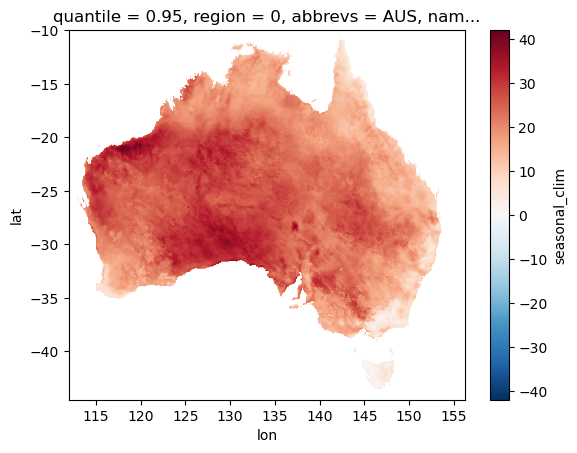

In [38]:
(FD.sel(model=13)-FD.sel(model=32)).plot()

##  Observations

In [30]:
FM=ds1.FFDI_mean.mean(dim='model')
FS=ds1.FFDI_mean.std(dim='model')
Rerr=FS/FM
Fdays=ds1.tot_days.mean(dim='model')
Fmean=ds1.seasonal_clim.mean(dim='model')

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/obs_ffdi_extreme_sa_2090.png


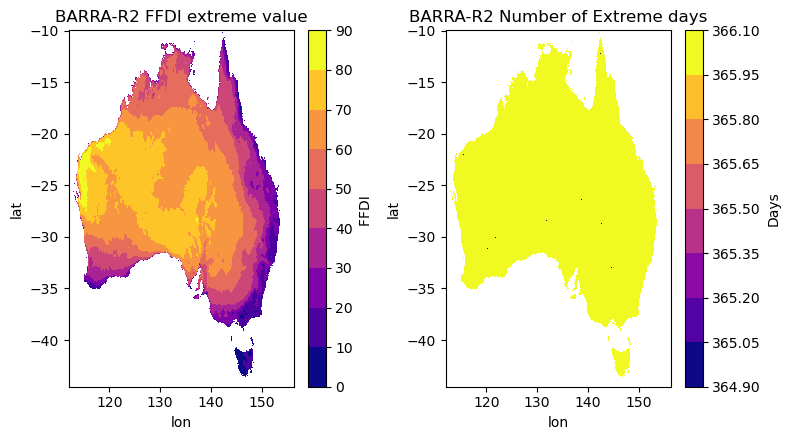

In [31]:
# plot FFDI extreme and relative error
plt.figure(figsize=(8,4.5))
plt.subplot(1,2,1)
ax=FM.plot(cmap='plasma',levels=10)
colorbar=ax.colorbar
ax=plt.title('BARRA-R2 FFDI extreme value')
colorbar.set_label('FFDI ')            

plt.subplot(1,2,2)
ax=Fdays.sum(dim='season',skipna=False).plot(cmap='plasma',levels=10)
colorbar=ax.colorbar
ax=plt.title('BARRA-R2 Number of Extreme days')
colorbar.set_label('Days')
ax=plt.tight_layout()


fname=dirsave+'obs_ffdi_extreme_'+dirstore+'.png'
print(fname)
plt.savefig(fname, dpi=150, bbox_inches="tight")

/g/data/xv83/rxm599/acs/hazard_fire/paper2/figs/obs_season_days_sa_2090.png
['DJF' 'JJA' 'MAM' 'SON']


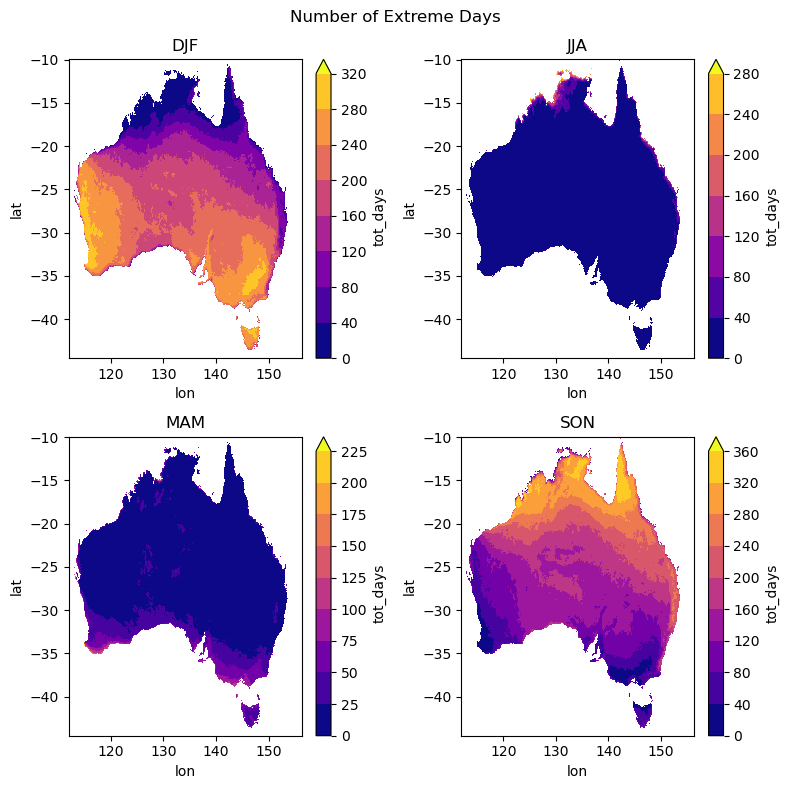

In [32]:
SM2=Fdays
#SM2=Fmean
nvar=SM2.season.values
fname=dirsave+'obs_season_days_'+dirstore+'.png'
lev = np.linspace(0, 360, 19)
lev=10
titl='Number of Extreme Days'
print(fname)
print(nvar)
plot_4o(SM2,Rerr,'season',nvar,lev, titl, fname)

In [33]:
ds2

<xarray.Dataset>
Dimensions:        (lat: 691, lon: 886, model: 39, season: 4)
Coordinates:
  * lat            (lat) float64 -44.5 -44.45 -44.4 ... -10.1 -10.05 -10.0
  * lon            (lon) float64 112.0 112.0 112.1 112.2 ... 156.2 156.2 156.2
    quantile       float64 0.95
    region         int64 0
    abbrevs        <U3 'AUS'
    names          <U9 'Australia'
  * season         (season) <U3 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: model
Data variables:
    FFDI_mean      (model, lat, lon) float64 dask.array<chunksize=(1, 691, 886), meta=np.ndarray>
    tot_days       (model, lat, lon, season) float64 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>
    seasonal_clim  (model, lat, lon, season) float32 dask.array<chunksize=(1, 691, 886, 4), meta=np.ndarray>